#1 : Chargement des librairies et des fichiers

##1.1 : Librairies

In [59]:
#Indispensables
import numpy as np
import pandas as pd
import math

#Graphiques
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#Données manquantes
from sklearn.impute import KNNImputer

##1.2 : Fichiers

In [60]:
#2.1
df_pop = pd.read_csv("Population_2000_2018.csv",sep=",")
#2.2
df_dispo_alimentaire = pd.read_csv("DisponibiliteAlimentaire_2017.csv",sep=",")
#2.3
df_code_pays = pd.read_excel("geo_cepii.xls")
df_dist_pays = pd.read_excel("dist_cepii.xls")
#2.4
df_inflation=pd.read_csv("inflation_2017.csv", sep=",", header=2, on_bad_lines='skip', encoding='utf-8', quotechar='"', quoting=0)
#2.5
df_pol_eco=pd.read_csv("pol_eco_data.csv", sep=",")
#2.6
df_prix_production=pd.read_csv("prix_production.csv", sep=",")
#2.7
df_taux_change=pd.read_csv("taux_change.csv", sep=",")

In [61]:
#Affichons les dataframes en entier

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

#2 : Préparation de chaque fichier

##2.1 : Population

In [62]:
df_pop.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680.871,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726.684,X,Sources internationales sûres,NaN


In [63]:
##On ramène la population à la bonne unité

df_pop['Population totale']=df_pop['Valeur']*1000

In [64]:
##On conserve les colonnes pertinentes à nos analyses

df_pop=df_pop[['Zone','Année','Population totale']]

In [65]:
##On pivote la table pour garder un format de données exploitable

pivot_pop=df_pop.pivot_table(index='Zone', columns='Année', values='Population totale', aggfunc='sum').reset_index()

In [66]:
pivot_pop.head()

Année,Zone,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Afghanistan,20779953.0,21606988.0,22600770.0,23680871.0,24726684.0,25654277.0,26433049.0,27100536.0,27722276.0,28394813.0,29185507.0,30117413.0,31161376.0,32269589.0,33370794.0,34413603.0,35383032.0,36296113.0,37171921.0
1,Afrique du Sud,44967708.0,45571274.0,46150913.0,46719196.0,47291610.0,47880601.0,48489459.0,49119759.0,49779471.0,50477011.0,51216964.0,52003755.0,52832658.0,53687121.0,54544186.0,55386367.0,56207646.0,57009756.0,57792518.0
2,Albanie,3129243.0,3129704.0,3126187.0,3118023.0,3104892.0,3086810.0,3063021.0,3033998.0,3002678.0,2973048.0,2948023.0,2928592.0,2914096.0,2903790.0,2896305.0,2890513.0,2886438.0,2884169.0,2882740.0
3,Algérie,31042235.0,31451514.0,31855109.0,32264157.0,32692163.0,33149724.0,33641002.0,34166972.0,34730608.0,35333881.0,35977455.0,36661445.0,37383895.0,38140133.0,38923692.0,39728025.0,40551392.0,41389189.0,42228408.0
4,Allemagne,81400882.0,81453885.0,81535122.0,81614380.0,81646474.0,81602741.0,81472226.0,81277830.0,81065752.0,80899961.0,80827002.0,80855632.0,80972628.0,81174367.0,81450378.0,81787411.0,82193768.0,82658409.0,83124418.0


In [67]:
##Affichage du nom des colonnes de pivot_pop

print(pivot_pop.columns)

##Attention : étiquettes de colonnes en format int

Index(['Zone',   2000,   2001,   2002,   2003,   2004,   2005,   2006,   2007,
         2008,   2009,   2010,   2011,   2012,   2013,   2014,   2015,   2016,
         2017,   2018],
      dtype='object', name='Année')


In [68]:
##Simplification et renaming

pivot_pop=pivot_pop[['Zone',2000,2017,2018]]
pivot_pop = pivot_pop.rename(columns={
    2000: 'Population (2000)',
    2017:'Population (2017)',
    2018:'Population (2018)'
  })

In [69]:
pivot_pop.head()

Année,Zone,Population (2000),Population (2017),Population (2018)
0,Afghanistan,20779953.0,36296113.0,37171921.0
1,Afrique du Sud,44967708.0,57009756.0,57792518.0
2,Albanie,3129243.0,2884169.0,2882740.0
3,Algérie,31042235.0,41389189.0,42228408.0
4,Allemagne,81400882.0,82658409.0,83124418.0


In [70]:
##Calcul de la croissance démographique sur la période

pivot_pop['Croissance démographique 2000-2018 (%)']=round((pivot_pop['Population (2018)']-pivot_pop['Population (2000)'])/pivot_pop['Population (2000)']*100,2)

In [71]:
##Dernière simplification

pivot_pop=pivot_pop[['Zone','Population (2017)','Croissance démographique 2000-2018 (%)']]
pivot_pop.head()

Année,Zone,Population (2017),Croissance démographique 2000-2018 (%)
0,Afghanistan,36296113.0,78.88
1,Afrique du Sud,57009756.0,28.52
2,Albanie,2884169.0,-7.88
3,Algérie,41389189.0,36.04
4,Allemagne,82658409.0,2.12


##2.2 : Disponibilté Alimentaire

In [72]:
df_dispo_alimentaire.head(20)

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.00,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.00,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.00,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.00,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.00,S,Données standardisées
5,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5521,Aliments pour animaux,2511,Blé et produits,2017,2017,Milliers de tonnes,76.00,S,Données standardisées
6,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5527,Semences,2511,Blé et produits,2017,2017,Milliers de tonnes,344.00,S,Données standardisées
7,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5123,Pertes,2511,Blé et produits,2017,2017,Milliers de tonnes,642.00,S,Données standardisées
8,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5170,Résidus,2511,Blé et produits,2017,2017,Milliers de tonnes,0.00,S,Données standardisées
9,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5142,Nourriture,2511,Blé et produits,2017,2017,Milliers de tonnes,5640.00,S,Données standardisées


In [73]:
##On affiche la liste des produits alimentaires répertoriés dans le df

df_dispo_alimentaire['Produit'].unique()

array(['Blé et produits', 'Riz et produits', 'Orge et produits',
       'Maïs et produits', 'Seigle et produits', 'Avoine',
       'Millet et produits', 'Sorgho et produits', 'Céréales, Autres',
       'Pommes de Terre et produits', 'Ignames', 'Racines nda',
       'Sucre, canne', 'Sucre, betterave', 'Sucre Eq Brut',
       'Edulcorants Autres', 'Miel', 'Haricots', 'Pois',
       'Légumineuses Autres et produits', 'Noix et produits', 'Soja',
       'Arachides Decortiquees', 'Graines de tournesol',
       'Graines Colza/Moutarde', 'Graines de coton', 'Coco (Incl Coprah)',
       'Sésame', 'Olives', 'Plantes Oleiferes, Autre', 'Huile de Soja',
       "Huile d'Arachide", 'Huile de Tournesol',
       'Huile de Colza&Moutarde', 'Huile Graines de Coton',
       'Huile de Palmistes', 'Huile de Palme', 'Huile de Coco',
       'Huile de Sésame', "Huile d'Olive", 'Huile de Son de Riz',
       'Huile de Germe de Maïs', 'Huil Plantes Oleif Autr',
       'Tomates et produits', 'Oignons', 'Légumes, 

In [74]:
##On conservee uniquement les lignes correspondant à la volaille (on amalgamera volailles et poulet)

df_dispo_alimentaire=df_dispo_alimentaire.loc[df_dispo_alimentaire['Produit']=='Viande de Volailles']

In [75]:
df_dispo_alimentaire.head()

### Attention aux unités : poids en milliers de tonnes, disponibiltés en Kcal/personne/jour, g/pers/jour, kg/pers/jour

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
651,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2734,Viande de Volailles,2017,2017,Milliers de tonnes,28.0,S,Données standardisées
652,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2734,Viande de Volailles,2017,2017,Milliers de tonnes,29.0,S,Données standardisées
653,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2734,Viande de Volailles,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
654,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2734,Viande de Volailles,2017,2017,Milliers de tonnes,57.0,S,Données standardisées
655,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5123,Pertes,2734,Viande de Volailles,2017,2017,Milliers de tonnes,2.0,S,Données standardisées


In [76]:
##On conserve uniquement les données pertinentes

df_dispo_alimentaire.drop(['Code Domaine', 'Domaine', 'Code zone', 'Code Élément', 'Code Produit', 'Code année', 'Année', 'Unité', 'Symbole','Description du Symbole','Produit'],axis='columns',inplace=True)

In [77]:
## Puis on pivote la table
pivot_dispo_poulet=df_dispo_alimentaire.pivot_table(index='Zone', columns='Élément', values='Valeur', aggfunc='sum').reset_index()

pivot_dispo_poulet.head(10)

Élément,Zone,Alimentation pour touristes,Aliments pour animaux,Autres utilisations (non alimentaire),Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Résidus,Semences,Traitement,Variation de stock
0,Afghanistan,NaN,NaN,NaN,5.0,1.53,0.33,0.54,57.0,NaN,29.0,55.0,2.0,28.0,0.0,NaN,NaN,0.0
1,Afrique du Sud,0.0,NaN,NaN,143.0,35.69,9.25,14.11,2118.0,63.0,514.0,2035.0,83.0,1667.0,0.0,NaN,NaN,0.0
2,Albanie,NaN,NaN,NaN,85.0,16.36,6.45,6.26,47.0,0.0,38.0,47.0,NaN,13.0,0.0,NaN,NaN,4.0
3,Algérie,0.0,NaN,NaN,22.0,6.38,1.50,1.97,277.0,0.0,2.0,264.0,13.0,275.0,0.0,NaN,NaN,0.0
4,Allemagne,NaN,NaN,NaN,71.0,19.47,4.16,7.96,1739.0,646.0,842.0,1609.0,NaN,1514.0,-38.0,NaN,167.0,-29.0
5,Angola,0.0,NaN,NaN,35.0,10.56,2.22,3.60,319.0,0.0,277.0,315.0,2.0,42.0,0.0,NaN,2.0,0.0
6,Antigua-et-Barbuda,2.0,NaN,0.0,233.0,54.10,17.55,17.77,7.0,0.0,7.0,5.0,NaN,0.0,0.0,NaN,NaN,0.0
7,Arabie saoudite,NaN,NaN,NaN,151.0,43.36,9.38,15.57,1435.0,10.0,722.0,1435.0,NaN,616.0,0.0,NaN,NaN,-108.0
8,Argentine,NaN,NaN,NaN,182.0,42.24,13.84,13.53,1962.0,207.0,8.0,1856.0,106.0,2161.0,0.0,NaN,NaN,0.0
9,Arménie,NaN,NaN,NaN,54.0,16.06,3.39,5.44,47.0,0.0,35.0,47.0,0.0,11.0,0.0,NaN,NaN,-2.0


In [78]:
##On conserve uniquement les colonnes pertinentes

pivot_dispo_poulet=pivot_dispo_poulet[['Zone','Disponibilité alimentaire en quantité (kg/personne/an)','Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 'Nourriture', 'Production']]

In [79]:
## On renomme les colonnes pour afficher les unités

pivot_dispo_poulet.rename(columns={
    'Disponibilité intérieure' : 'Disponibilité intérieure (x1000 T)',
    'Exportations - Quantité' : 'Exportations - Quantité (x1000 T)',
    'Importations - Quantité' : 'Importations - Quantité (x1000 T)',
    'Nourriture' : 'Nourriture (x1000 T)',
    'Production' : 'Production (x1000 T)'
}, inplace=True)

pivot_dispo_poulet.head()

Élément,Zone,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure (x1000 T),Exportations - Quantité (x1000 T),Importations - Quantité (x1000 T),Nourriture (x1000 T),Production (x1000 T)
0,Afghanistan,1.53,57.0,NaN,29.0,55.0,28.0
1,Afrique du Sud,35.69,2118.0,63.0,514.0,2035.0,1667.0
2,Albanie,16.36,47.0,0.0,38.0,47.0,13.0
3,Algérie,6.38,277.0,0.0,2.0,264.0,275.0
4,Allemagne,19.47,1739.0,646.0,842.0,1609.0,1514.0


##2.3 : Distance entre les pays

In [80]:
#Premier fichier : liste des pays

df_code_pays.head()

,iso2,iso3,cnum,country,pays,area,dis_int,landlocked,continent,city_en,city_fr,lat,lon,cap,maincity,citynum,langoff_1,langoff_2,langoff_3,lang20_1,lang20_2,lang20_3,lang20_4,lang9_1,lang9_2,lang9_3,lang9_4,colonizer1,colonizer2,colonizer3,colonizer4,short_colonizer1,short_colonizer2,short_colonizer3
0,AW,ABW,533,Aruba,Aruba,193,5.225315,0,America,Oranjestad,Oranjestad,12.550000,-70.10000,1,1,2,Dutch,Spanish,.,Dutch,English,Papiamento,.,.,.,.,.,NLD,.,.,.,.,.,.
1,AF,AFG,4,Afghanistan,Afghanistan,652225,303.761400,1,Asia,Kabul,Kaboul,34.516670,69.20000,1,1,25,Persian,.,.,Persian,Pashtu,.,.,Hazaragi,Uzbek,.,.,.,.,.,.,GBR,.,.
2,AO,AGO,24,Angola,Angola,1246700,419.966600,0,Africa,Luanda,Luanda,-8.833333,13.25000,1,1,25,Portuguese,.,.,Portuguese,Umbundu,Mbundu Loanda,.,Kongo,.,.,.,PRT,.,.,.,.,.,.
3,AI,AIA,660,Anguilla,Anguilla,102,3.798690,0,America,The Valley,The Valley,18.216670,-63.06667,1,1,2,English,.,.,English,Leeward Caribbean Creole English,.,.,.,.,.,.,GBR,.,.,.,.,.,.
4,AL,ALB,8,Albania,Albanie,28748,63.773110,0,Europe,Tirana,Tirana,41.333330,19.81667,1,1,25,Albanian,.,.,Albanian,.,.,.,.,.,.,.,TUR,.,.,.,.,.,.


In [81]:
#Second fichier : matrice des distances entre chaque paire de pays

df_dist_pays.head()

,iso_o,iso_d,contig,comlang_off,comlang_ethno,colony,comcol,curcol,col45,smctry,dist,distcap,distw,distwces
0,ABW,ABW,0,0,0,0,0,0,0,0,5.225315,5.225315,25.09354,23.04723
1,ABW,AFG,0,0,0,0,0,0,0,0,13257.810000,13257.810000,13168.22,13166.37
2,ABW,AGO,0,0,0,0,0,0,0,0,9516.913000,9516.913000,9587.316,9584.193
3,ABW,AIA,0,0,1,0,0,0,0,0,983.268200,983.268200,976.8974,976.8916
4,ABW,ALB,0,0,0,0,0,0,0,0,9091.742000,9091.742000,9091.576,9091.466


In [82]:
##On conserve les distances relatives à la France et simplifie le dataframe avant la jointure

df_dist_pays=df_dist_pays.loc[(df_dist_pays['iso_o']=='FRA')]
df_dist_pays=df_dist_pays[['iso_d','distcap']]

df_dist_pays.head()

,iso_d,distcap
15008,ABW,7685.884
15009,AFG,5590.381
15010,AGO,6510.322
15011,AIA,6710.570
15012,ALB,1603.534


In [83]:
##On simplifie le second dataframe

df_code_pays=df_code_pays[['iso3','pays']]

df_code_pays.head()

,iso3,pays
0,ABW,Aruba
1,AFG,Afghanistan
2,AGO,Angola
3,AIA,Anguilla
4,ALB,Albanie


In [84]:
##On joint les deux df pour avoir les noms des pays à côté des distances
df_liste_dist_pays=pd.merge(df_dist_pays,df_code_pays,how='inner',left_on='iso_d',right_on='iso3')

##Puis on simplifie en retirant les codes
df_liste_dist_pays=df_liste_dist_pays[['pays','distcap']]

##N'oublions pas de clarifier le naming
df_liste_dist_pays.rename(columns={'pays':'Zone','distcap':'Distance entre la capitale et Paris (km)'},inplace=True)

df_liste_dist_pays.head()

,Zone,Distance entre la capitale et Paris (km)
0,Aruba,7685.884
1,Afghanistan,5590.381
2,Angola,6510.322
3,Anguilla,6710.570
4,Albanie,1603.534


##2.4 : Inflation

In [85]:
df_inflation.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Inflation, prix à la consommation (% annuel)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.032258,1.073966,3.643045,3.121868,3.991628,5.836688,5.555556,3.873375,5.215560,6.311080,3.361391,3.225288,2.999948,1.869489,2.280372,4.044021,2.883604,3.315247,3.656365,2.529129,3.397787,3.608024,5.392568,8.955987,-2.135429,2.078141,4.316297,0.627472,-2.372065,0.421441,0.474764,-0.931196,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,AFE,"Inflation, prix à la consommation (% annuel)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.598394,15.224099,11.216481,14.238055,12.526893,15.06985,15.066512,14.461591,12.139918,11.567524,10.983863,13.006566,13.891972,12.563443,12.522258,12.558202,12.457914,17.678100,16.167612,13.135661,14.852815,12.288591,9.706586,10.249599,7.495255,7.819865,8.601485,5.840354,8.763755,7.449700,5.023421,8.558038,8.898164,8.450775,12.566645,8.954218,5.537538,8.971206,9.158708,5.748831,5.525819,5.098562,6.446877,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.489789,NaN
2,Afghanistan,AFG,"Inflation, prix à la consommation (% annuel)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.686269,6.784597,8.680571,26.418664,-6.811161,2.178538,11.804186,6.441213,7.385772,4.673996,-0.661709,4.383892,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN
3,NaN,AFW,"Inflation, prix à la consommation (% annuel)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.799211,12.059765,10.671937,11.250000,7.354926,5.950965,0.248789,2.523659,0.869287,1.057361,1.741888,-0.062999,0.553456,31.841017,10.563289,4.914240,3.997142,4.471125,0.372266,2.530775,4.361529,3.188693,1.760904,0.694336,5.631634,4.415900,3.607368,8.452976,3.282440,1.784844,4.018699,4.578375,2.439201,1.768436,2.130817,1.487416,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,NaN
4,Angola,AGO,"Inflation, prix à la consommation (% annuel)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.783784,299.509804,1378.527607,949.792531,2666.450593,4145.105982,219.176721,107.284822,248.195902,324.996872,152.561022,108.897436,98.224144,43.542107,22.953514,13.305210,12.251497,12.475829,13.730284,14.469656,13.482468,10.277905,8.777814,7.280387,9.355972,30.694415,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,NaN


In [86]:
##On conserve les colonnes pertinentes
df_inflation=df_inflation[['Country Code','2015','2016','2017','2018']]

##On calcule la moyenne des inflations annuelles entre 2015 et 2018
df_inflation['Inflation moyenne (2015-2018) (%)']=round(((df_inflation['2015']+df_inflation['2016']+df_inflation['2017']+df_inflation['2017']+df_inflation['2018'])/4),2)
#df_inflation.head()

##Attention, il semble y avoir des erreurs dans la colonne pays (cf NaN en ligne 3 du précédent affichage .head) :
##On repart des codes pays et on match avec la liste des pays geo_cepii
df_inflation_clean=pd.merge(df_inflation,df_code_pays,how='inner',left_on='Country Code',right_on='iso3')

df_inflation_clean.head()

,Country Code,2015,2016,2017,2018,Inflation moyenne (2015-2018) (%),iso3,pays
0,ABW,0.474764,-0.931196,-1.028282,3.626041,0.28,ABW,Aruba
1,AFG,-0.661709,4.383892,4.975952,0.626149,3.58,AFG,Afghanistan
2,AGO,9.355972,30.694415,29.844480,19.628938,29.84,AGO,Angola
3,ALB,1.896174,1.275432,1.986661,2.028060,2.29,ALB,Albanie
4,AND,NaN,NaN,NaN,NaN,NaN,AND,Andorre


In [87]:
##Dernière simplification des colonnes et renaming

df_inflation_clean=df_inflation_clean[['pays','Inflation moyenne (2015-2018) (%)']]
df_inflation_clean.rename(columns={'pays':'Zone'},inplace=True)

df_inflation_clean.head()

,Zone,Inflation moyenne (2015-2018) (%)
0,Aruba,0.28
1,Afghanistan,3.58
2,Angola,29.84
3,Albanie,2.29
4,Andorre,NaN


##2.5 : Indicateurs politiques

In [88]:
df_pol_eco.head()

,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,FS,Données de la sécurité alimentaire,4,Afghanistan,6121,Valeur,21012,"Part des céréales, des racines et des tubercul...",20162018,2016-2018,%,71,E,Valeur estimée,NaN
1,FS,Données de la sécurité alimentaire,4,Afghanistan,6126,Valeur,22013,"PIB par habitant, ($ PPA internationaux consta...",2017,2017,Int$/cap,2953,X,Chiffre de source externe,NaN
2,FS,Données de la sécurité alimentaire,4,Afghanistan,6121,Valeur,210041,Prévalence de la sous-alimentation (%) (moyenn...,20162018,2016-2018,%,21.3,E,Valeur estimée,NaN
3,FS,Données de la sécurité alimentaire,4,Afghanistan,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2017,2017,NaN,-2.79,X,Chiffre de source externe,NaN
4,FS,Données de la sécurité alimentaire,710,Afrique du Sud,6121,Valeur,21012,"Part des céréales, des racines et des tubercul...",20162018,2016-2018,%,51,E,Valeur estimée,NaN


In [89]:
##Simplification
df_pol_eco=df_pol_eco[['Zone','Produit','Valeur']]

##Pivot
pivot_pol_eco = df_pol_eco.pivot_table(index='Zone', columns='Produit', values='Valeur',aggfunc='sum').reset_index()

pivot_pol_eco.head()

Produit,Zone,"PIB par habitant, ($ PPA internationaux constants de 2021)","Part des céréales, des racines et des tubercules dans les apports énergétiques alimentaires (%) (moyenne sur 3 ans)",Prévalence de la sous-alimentation (%) (moyenne sur 3 ans),Stabilité politique et absence de violence/terrorisme (indice)
0,Afghanistan,2953,71,21.3,-2.79
1,Afrique du Sud,14591,51,6.1,-0.28
2,Albanie,14155,34,4.3,0.37
3,Algérie,15428,48,2.5,-0.92
4,Allemagne,61992,27,<2.5,0.57


##2.6 : Prix du poulet à la production

In [90]:
df_prix_production.head()

,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit (CPC),Produit,Code année,Année,Code Mois,Mois,Unité,Valeur,Symbole,Description du Symbole
0,PP,Prix à la Production,710,Afrique du Sud,5532,Prix à la Production (USD/tonne),21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,7021,Valeur annuel,USD,2015.1,A,Chiffre officiel
1,PP,Prix à la Production,12,Algérie,5532,Prix à la Production (USD/tonne),21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,7021,Valeur annuel,USD,2180.7,A,Chiffre officiel
2,PP,Prix à la Production,276,Allemagne,5532,Prix à la Production (USD/tonne),21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,7021,Valeur annuel,USD,1459.5,A,Chiffre officiel
3,PP,Prix à la Production,32,Argentine,5532,Prix à la Production (USD/tonne),21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,7021,Valeur annuel,USD,1324.1,A,Chiffre officiel
4,PP,Prix à la Production,51,Arménie,5532,Prix à la Production (USD/tonne),21121,"Viande, poulet, fraîche ou réfrigérée",2017,2017,7021,Valeur annuel,USD,3741.2,A,Chiffre officiel


In [91]:
##Simplification et renaming

df_prix_production=df_prix_production[['Zone','Valeur']]
df_prix_production.rename(columns={'Valeur':'Prix de la tonne de poulet à la production (USD)'},inplace=True)

df_prix_production.head()

,Zone,Prix de la tonne de poulet à la production (USD)
0,Afrique du Sud,2015.1
1,Algérie,2180.7
2,Allemagne,1459.5
3,Argentine,1324.1
4,Arménie,3741.2


In [92]:
df_prix_production.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 2 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Zone                                              44 non-null     object 
 1   Prix de la tonne de poulet à la production (USD)  44 non-null     float64
dtypes: float64(1), object(1)
memory usage: 836.0+ bytes


C'est dommage, la métrique est intéressante, mais 44 pays avec des données c'est insuffisant

#3 : Jointures et DF final

On va procéder aux jointures successives et nettoyer le df_final

##3.1 : Assemblage des données

In [93]:
## Jointure de pivot_pop (cf 2.1) et pivot_dispo_poulet (cf2.2)

df_final=pd.merge(pivot_pop,pivot_dispo_poulet,how='inner',on='Zone')
#df_final.head()


In [94]:
##A ce stade, il est intéressant de mettre à profit ces deux tables pour calculer la consommation de poulet par habitant

df_final['Consommation de poulet annuelle par habitant (kg)']=round((df_final['Nourriture (x1000 T)']*1000000)/df_final['Population (2017)'],2)
#df_final.head()

In [95]:
##On joint df_liste_dist_pays (cf 2.3)

df_final=pd.merge(df_final,df_liste_dist_pays,how='left',on='Zone')
df_final.drop_duplicates(inplace=True)
#df_final.head()

In [96]:
##On joint df_inflation_clean (cf 2.4)

df_final=pd.merge(df_final,df_inflation_clean,how='left',on='Zone')
df_final.drop_duplicates(inplace=True)
#df_final.head()

In [97]:
##On joint pivot_pol_eco (cf 2.5)

df_final=pd.merge(df_final,pivot_pol_eco,how='inner',on='Zone')
df_final.drop_duplicates()
#df_final.head()

,Zone,Population (2017),Croissance démographique 2000-2018 (%),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure (x1000 T),Exportations - Quantité (x1000 T),Importations - Quantité (x1000 T),Nourriture (x1000 T),Production (x1000 T),Consommation de poulet annuelle par habitant (kg),Distance entre la capitale et Paris (km),Inflation moyenne (2015-2018) (%),"PIB par habitant, ($ PPA internationaux constants de 2021)","Part des céréales, des racines et des tubercules dans les apports énergétiques alimentaires (%) (moyenne sur 3 ans)",Prévalence de la sous-alimentation (%) (moyenne sur 3 ans),Stabilité politique et absence de violence/terrorisme (indice)
0,Afghanistan,3.629611e+07,78.88,1.53,57.0,NaN,29.0,55.0,28.0,1.52,5590.3810,3.58,2953,71,21.3,-2.79
1,Afrique du Sud,5.700976e+07,28.52,35.69,2118.0,63.0,514.0,2035.0,1667.0,35.70,8692.8120,6.50,14591,51,6.1,-0.28
2,Albanie,2.884169e+06,-7.88,16.36,47.0,0.0,38.0,47.0,13.0,16.30,1603.5340,2.29,14155,34,4.3,0.37
3,Algérie,4.138919e+07,36.04,6.38,277.0,0.0,2.0,264.0,275.0,6.38,1340.3900,6.66,15428,48,2.5,-0.92
4,Allemagne,8.265841e+07,2.12,19.47,1739.0,646.0,842.0,1609.0,1514.0,19.47,880.1870,1.44,61992,27,<2.5,0.57
5,Angola,2.981677e+07,87.92,10.56,319.0,0.0,277.0,315.0,42.0,10.56,6510.3220,29.84,9042,61,15.4,-0.39
6,Antigua-et-Barbuda,9.542600e+04,26.67,54.10,7.0,0.0,7.0,5.0,0.0,52.40,6708.7700,1.64,27199,27,0,0.73
7,Arabie saoudite,3.310118e+07,63.10,43.36,1435.0,10.0,722.0,1435.0,616.0,43.35,4694.5000,1.02,57943,47,<2.5,-0.65
8,Argentine,4.393714e+07,20.32,42.24,1962.0,207.0,8.0,1856.0,2161.0,42.24,11072.2500,NaN,28335,35,3.5,0.16
9,Arménie,2.944791e+06,-3.84,16.06,47.0,0.0,35.0,47.0,11.0,15.96,3434.0710,1.70,14244,40,<2.5,-0.63


##3.2 : Nettoyage de df_final

A ce stade, nos données sont rassemblées dans le même dataframe.
Celui-ci ne possède aucune lignes en double.

Dans le dernier aperçu, on peut toutefois remarquer quelques nettoyages supplémentaires à effectuer (celulles NaN, <2.5 dans la colonne sous-alimentation)

In [98]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 16 columns):
 #   Column                                                                                                               Non-Null Count  Dtype  
---  ------                                                                                                               --------------  -----  
 0   Zone                                                                                                                 170 non-null    object 
 1   Population (2017)                                                                                                    170 non-null    float64
 2   Croissance démographique 2000-2018 (%)                                                                               167 non-null    float64
 3   Disponibilité alimentaire en quantité (kg/personne/an)                                                               170 non-null    float64
 4   Disponibilité 

###3.2.1 : Corrections de typing

In [99]:
## On s'attend à ce que les colonnes 12 à 15 soient des float

## Commençons par la variable PIB

print(df_final['PIB par habitant, ($ PPA internationaux constants de 2021)'].unique())

## Rien d'étrange, on convertit directement

df_final['PIB par habitant, ($ PPA internationaux constants de 2021)']=pd.to_numeric(df_final['PIB par habitant, ($ PPA internationaux constants de 2021)'])

['2953' '14591' '14155' '15428' '61992' '9042' '27199' '57943' '28335'
 '14244' '56685' '62612' '19659' '33050' '6006' '18740' '58555' '11575'
 '9643' '15554' '17353' '17725' '26681' '2232' '25504' '3042' '8235'
 '5632' '4798' '56612' '27893' '65663' '133500' nan '42129' '16986' '7373'
 '22623' '32352' '5556' '64816' '5422' '16314' '10065' '45446' '39940'
 '9697' '13091' '55637' '51896' '35570' '19556' '2533' '5994' '16302'
 '31995' '11006' '3333' '2314' '12802' '16238' '3474' '6100' '33829'
 '7327' '11773' '15108' '14418' '87942' '63999' '42947' '48849' '9964'
 '44505' '9340' '31524' '4847' '5861' '2823' '52286' '2925' '33036'
 '16129' '1661' '38775' '132170' '20120' '1670' '29552' '1613' '20037'
 '2816' '51579' '8450' '24073' '6051' '21778' '14402' '22740' '1532'
 '5878' '11409' '7391' '1520' '5652' '87194' '46193' '4072' '38691' '2544'
 '8047' '5032' '31980' '15320' '8584' '34355' '37943' '15070' '32849'
 '51601' '2352' '1104' '44788' '13119' '19502' '7433' '3319' '29949'
 '15533' '

In [100]:
## Poursuivons avec la variable de la part des céréales dans l'alimentation

print(df_final['Part des céréales, des racines et des tubercules dans les apports énergétiques alimentaires (%) (moyenne sur 3 ans)'].unique())

## Ok pour la conversion
df_final['Part des céréales, des racines et des tubercules dans les apports énergétiques alimentaires (%) (moyenne sur 3 ans)']=pd.to_numeric(df_final['Part des céréales, des racines et des tubercules dans les apports énergétiques alimentaires (%) (moyenne sur 3 ans)'])


['71' '51' '34' '48' '27' '61' '47' '35' '40' '23' '53' '78' '32' '38'
 '43' '50' '65' '67' '77' '56' '42' '29' '31' '52' '33' '60' '30' '46'
 '26' '28' '55' '44' '49' '63' '62' '66' '58' '24' '37' '36' '79' '39'
 '69' '41' '64' '57' '68' '25' '70' '75']


In [101]:
## Poursuivons avec la sous_alimentation

print(df_final['Prévalence de la sous-alimentation (%) (moyenne sur 3 ans)'].unique())

## Ici on a un souci avec les champs '<2.5'
## On va les placer à la borne 2.5

df_final['Prévalence de la sous-alimentation (%) (moyenne sur 3 ans)'].replace(to_replace='<2.5',value='2.5',inplace=True)

## On peut maintenant convertir

df_final['Prévalence de la sous-alimentation (%) (moyenne sur 3 ans)']=pd.to_numeric(df_final['Prévalence de la sous-alimentation (%) (moyenne sur 3 ans)'])

['21.3' '6.1' '4.3' '2.5' '<2.5' '15.4' 0 '3.5' '13.4' '5.8' '14.2' '22.1'
 '3.4' '14' '10.5' '15.5' '6.3' '6' '3.1' '4.2' '30.2' '10.6' '12.6' '5.5'
 '7.6' '15' '7.3' '16.4' '8.8' '14.3' '13.6' '6.4' '40.3' '13.2' '8' '16'
 '9.2' '23.6' '3.2' '34.9' '2.9' '36' '17.6' '4.6' '6.6' '3.7' '6.8'
 '38.3' '20' '15.6' '11.1' '11.5' '7.4' '4.9' '7' '35.5' '11.7' '2.6'
 '7.8' '6.5' '31.9' '25.3' '5.9' '47.5' '22.6' '17.9' '26' '4.1' '10.3'
 '5' '9.3' '12.2' '26.7' '8.1' '16.2' '20.4' '7.1' '23.7' '31.8' '30.9'
 '10.4' '14.1']


/tmp/ipykernel_326/4207470257.py:8: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [102]:
## On termine avec la stabilité politique

print(df_final['Stabilité politique et absence de violence/terrorisme (indice)'].unique())

## Convertissons la variable

df_final['Stabilité politique et absence de violence/terrorisme (indice)']=pd.to_numeric(df_final['Stabilité politique et absence de violence/terrorisme (indice)'])

['-2.79' '-0.28' '0.37' '-0.92' '0.57' '-0.39' '0.73' '-0.65' '0.16'
 '-0.63' '0.88' '1.03' '-0.75' '0.98' '-1.25' '0.95' '0.42' '0.03' '-0.35'
 '1.01' '-0.48' '0.32' '-0.93' '-0.06' '0.76' '0.09' '-1.09' '1.09' '0.41'
 '0.82' '1.41' nan '0.53' '-0.78' '-0.53' '0.6' '0.68' '0.64' '0.85'
 '-0.73' '1.17' '-0.26' '0.27' '-0.27' '0.59' '1.06' '-0.64' '-0.11'
 '-0.09' '0.08' '0.99' '-0.08' '-0.7' '-0.5' '-0.05' '-0.38' '-0.68'
 '-0.57' '0.8' '-0.77' '-2.3' '1.34' '-0.89' '0.29' '0.3' '1.1' '-0.43'
 '0.02' '-1.13' '-0.36' '0.86' '-0.19' '0.45' '-1.62' '-0.32' '0.77'
 '1.31' '-0.3' '0.11' '-0.25' '0.22' '-1.9' '1.24' '0.96' '-0.81' '0.78'
 '-1.08' '0.62' '-1.26' '-2' '1.15' '1.56' '-0.58' '0.75' '-0.24' '-2.4'
 '0.38' '-1.19' '0.51' '1.11' '0.05' '-1.99' '-0.31' '0.15' '0.39' '0.63'
 '0.87' '0.97' '1.16' '0.18' '-0.04' '0.9' '-1.97' '0.12' '-0.67' '-1.29'
 '0.07' '-0.87' '-1.02' '-0.13' '-1.87' '1.04' '0.21' '-2.93' '0.14'
 '-0.71' '-1.43' '0.26' '-1.68' '0.19']


###3.2.2 : Données manquantes

Nous allons utilisé KNNimputer afin d'approximer les données manquantes

In [103]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 16 columns):
 #   Column                                                                                                               Non-Null Count  Dtype  
---  ------                                                                                                               --------------  -----  
 0   Zone                                                                                                                 170 non-null    object 
 1   Population (2017)                                                                                                    170 non-null    float64
 2   Croissance démographique 2000-2018 (%)                                                                               167 non-null    float64
 3   Disponibilité alimentaire en quantité (kg/personne/an)                                                               170 non-null    float64
 4   Disponibilité 

On est à au moins 75% de données non nulles pour chacune des colonnes, c'est pas mal

In [104]:
##  Ecartons d'abord la variables Exportations (104/134 valeurs possibles, c'est trop peu)

df_final.drop(['Exportations - Quantité (x1000 T)'],axis='columns',inplace=True)

In [105]:
##On retravaille rapidement la forme du df pour que KNNimputer fonctionne
##Les pays sont passés en index et sauvegardés dans la variables pays
##On sauvegarde également les colonnes dans la variables features

df_final.index=df_final["Zone"]
df_final.index.name = None

df_final=df_final.drop(columns="Zone")
pays=df_final.index
features=df_final.columns

df_final.head()

,Population (2017),Croissance démographique 2000-2018 (%),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure (x1000 T),Importations - Quantité (x1000 T),Nourriture (x1000 T),Production (x1000 T),Consommation de poulet annuelle par habitant (kg),Distance entre la capitale et Paris (km),Inflation moyenne (2015-2018) (%),"PIB par habitant, ($ PPA internationaux constants de 2021)","Part des céréales, des racines et des tubercules dans les apports énergétiques alimentaires (%) (moyenne sur 3 ans)",Prévalence de la sous-alimentation (%) (moyenne sur 3 ans),Stabilité politique et absence de violence/terrorisme (indice)
Afghanistan,36296113.0,78.88,1.53,57.0,29.0,55.0,28.0,1.52,5590.381,3.58,2953.0,71,21.3,-2.79
Afrique du Sud,57009756.0,28.52,35.69,2118.0,514.0,2035.0,1667.0,35.70,8692.812,6.50,14591.0,51,6.1,-0.28
Albanie,2884169.0,-7.88,16.36,47.0,38.0,47.0,13.0,16.30,1603.534,2.29,14155.0,34,4.3,0.37
Algérie,41389189.0,36.04,6.38,277.0,2.0,264.0,275.0,6.38,1340.390,6.66,15428.0,48,2.5,-0.92
Allemagne,82658409.0,2.12,19.47,1739.0,842.0,1609.0,1514.0,19.47,880.187,1.44,61992.0,27,2.5,0.57


In [106]:
## On utilise maintenant KNNImputer pour traiter les NaN restants

## Cette fonction utilise les k (ici 5) plus proches individus pour calculer les données pour combler les NaN
imputer = KNNImputer(n_neighbors=5, weights="uniform")

# On applique l'imputation et reforme le df
df_final = pd.DataFrame(imputer.fit_transform(df_final), columns=df_final.columns, index=pays)

In [107]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 170 entries, Afghanistan to Îles Salomon
Data columns (total 14 columns):
 #   Column                                                                                                               Non-Null Count  Dtype  
---  ------                                                                                                               --------------  -----  
 0   Population (2017)                                                                                                    170 non-null    float64
 1   Croissance démographique 2000-2018 (%)                                                                               170 non-null    float64
 2   Disponibilité alimentaire en quantité (kg/personne/an)                                                               170 non-null    float64
 3   Disponibilité intérieure (x1000 T)                                                                                   170 non-null    float64
 4   

In [108]:
df_final

,Population (2017),Croissance démographique 2000-2018 (%),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure (x1000 T),Importations - Quantité (x1000 T),Nourriture (x1000 T),Production (x1000 T),Consommation de poulet annuelle par habitant (kg),Distance entre la capitale et Paris (km),Inflation moyenne (2015-2018) (%),"PIB par habitant, ($ PPA internationaux constants de 2021)","Part des céréales, des racines et des tubercules dans les apports énergétiques alimentaires (%) (moyenne sur 3 ans)",Prévalence de la sous-alimentation (%) (moyenne sur 3 ans),Stabilité politique et absence de violence/terrorisme (indice)
Afghanistan,3.629611e+07,78.880,1.53,57.0,29.0,55.0,28.0,1.520,5590.38100,3.580,2953.0,71.0,21.3,-2.790
Afrique du Sud,5.700976e+07,28.520,35.69,2118.0,514.0,2035.0,1667.0,35.700,8692.81200,6.500,14591.0,51.0,6.1,-0.280
Albanie,2.884169e+06,-7.880,16.36,47.0,38.0,47.0,13.0,16.300,1603.53400,2.290,14155.0,34.0,4.3,0.370
Algérie,4.138919e+07,36.040,6.38,277.0,2.0,264.0,275.0,6.380,1340.39000,6.660,15428.0,48.0,2.5,-0.920
Allemagne,8.265841e+07,2.120,19.47,1739.0,842.0,1609.0,1514.0,19.470,880.18700,1.440,61992.0,27.0,2.5,0.570
Angola,2.981677e+07,87.920,10.56,319.0,277.0,315.0,42.0,10.560,6510.32200,29.840,9042.0,61.0,15.4,-0.390
Antigua-et-Barbuda,9.542600e+04,26.670,54.10,7.0,7.0,5.0,0.0,52.400,6708.77000,1.640,27199.0,27.0,0.0,0.730
Arabie saoudite,3.310118e+07,63.100,43.36,1435.0,722.0,1435.0,616.0,43.350,4694.50000,1.020,57943.0,47.0,2.5,-0.650
Argentine,4.393714e+07,20.320,42.24,1962.0,8.0,1856.0,2161.0,42.240,11072.25000,16.046,28335.0,35.0,3.5,0.160
Arménie,2.944791e+06,-3.840,16.06,47.0,35.0,47.0,11.0,15.960,3434.07100,1.700,14244.0,40.0,2.5,-0.630


###3.2.3 : Simplification des noms de colonnes

Nous allons effectuer bientôt effectuer un PCA, les données seront normalisées : on peut se passer des unités et simplifier le nom des colonnes, qui compliquent l'affichage des graphiques

In [109]:
df_final.rename(columns={
    'Population (2017)':'Population',
    'Croissance démographique 2000-2018 (%)' : 'Croissance démographique',
    'Disponibilité alimentaire en quantité (kg/personne/an)':'Disponibilité alimentaire',
    'Disponibilité intérieure (x1000 T)' : 'Disponibilité intérieure',
    'Importations - Quantité (x1000 T)' : 'Importations',
    'Nourriture (x1000 T)' : 'Nourriture',
    'Production (x1000 T)' : 'Production',
    'Consommation de poulet annuelle par habitant (kg)' : 'Consommation de poulet',
    'Distance entre la capitale et Paris (km)' : 'Distance',
    'Inflation moyenne (2015-2018) (%)' : 'Inflation',
    'PIB par habitant, ($ PPA internationaux constants de 2021)' : 'PIB par hab',
    'Part des céréales, des racines et des tubercules dans les apports énergétiques alimentaires (%) (moyenne sur 3 ans)' : 'Part des céréales',
    'Prévalence de la sous-alimentation (%) (moyenne sur 3 ans)' : 'Sous-alimentation',
    'Stabilité politique et absence de violence/terrorisme (indice)' : 'Stabilité politique'},inplace=True)

On a maintenant un dataframe complet et propre.
Passons aux première analyses.

#4 : Analyses

In [110]:
df_final.head()

,Population,Croissance démographique,Disponibilité alimentaire,Disponibilité intérieure,Importations,Nourriture,Production,Consommation de poulet,Distance,Inflation,PIB par hab,Part des céréales,Sous-alimentation,Stabilité politique
Afghanistan,36296113.0,78.88,1.53,57.0,29.0,55.0,28.0,1.52,5590.381,3.58,2953.0,71.0,21.3,-2.79
Afrique du Sud,57009756.0,28.52,35.69,2118.0,514.0,2035.0,1667.0,35.70,8692.812,6.50,14591.0,51.0,6.1,-0.28
Albanie,2884169.0,-7.88,16.36,47.0,38.0,47.0,13.0,16.30,1603.534,2.29,14155.0,34.0,4.3,0.37
Algérie,41389189.0,36.04,6.38,277.0,2.0,264.0,275.0,6.38,1340.390,6.66,15428.0,48.0,2.5,-0.92
Allemagne,82658409.0,2.12,19.47,1739.0,842.0,1609.0,1514.0,19.47,880.187,1.44,61992.0,27.0,2.5,0.57


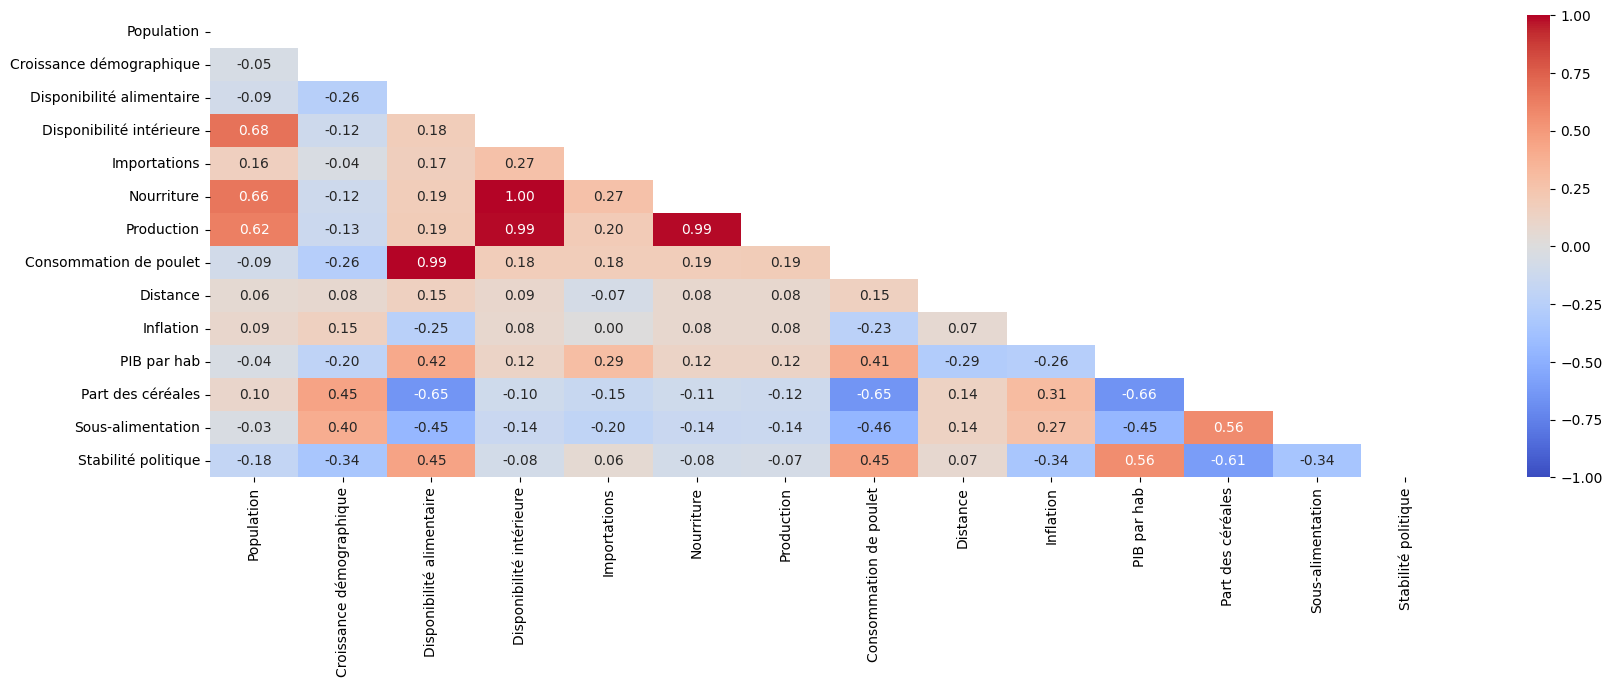

In [111]:
## Affichons la matrice de corrélations sous forme de demie heatmap

matrice_heatmap=df_final[['Population',
                          'Croissance démographique',
                          'Disponibilité alimentaire',
                          'Disponibilité intérieure',
                          'Importations',
                          'Nourriture',
                          'Production',
                          'Consommation de poulet',
                          'Distance',
                          'Inflation',
                          'PIB par hab',
                          'Part des céréales',
                          'Sous-alimentation',
                          'Stabilité politique']].corr()

mask = np.triu(np.ones_like(matrice_heatmap, dtype=bool))
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(matrice_heatmap, vmin=-1, vmax=1,annot=True, cmap='coolwarm',mask=mask,fmt="0.2f")
plt.show()

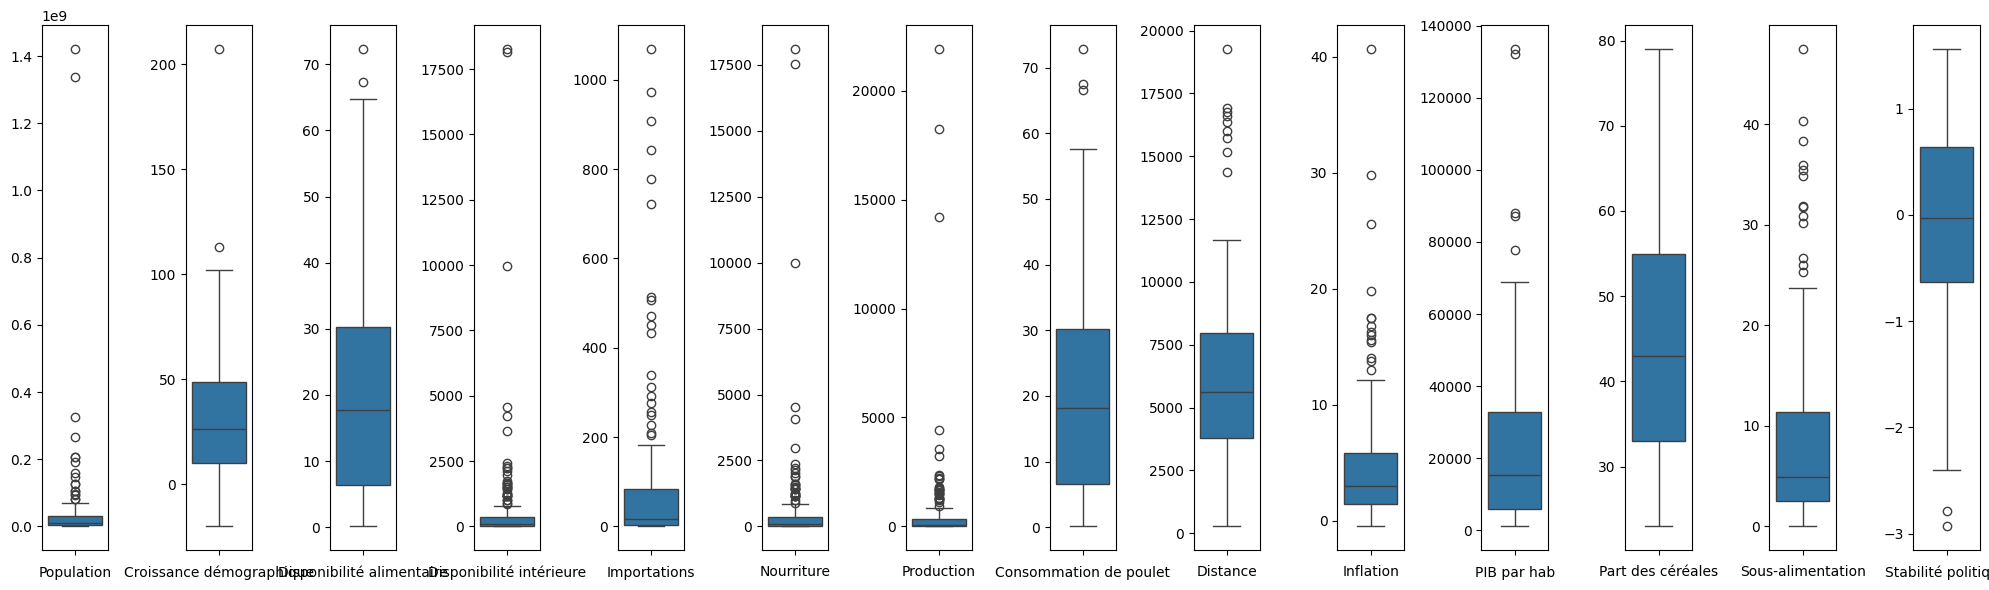

In [112]:
## Affichons les barplots pour chaque variable

columns_to_plot = ['Population',
                   'Croissance démographique',
                   'Disponibilité alimentaire',
                   'Disponibilité intérieure',
                   'Importations',
                   'Nourriture',
                   'Production',
                   'Consommation de poulet',
                   'Distance',
                   'Inflation',
                   'PIB par hab',
                   'Part des céréales',
                   'Sous-alimentation',
                   'Stabilité politique']

fig, axes = plt.subplots(ncols=len(columns_to_plot), figsize=(20, 6))

for column, axis in zip(columns_to_plot, axes):
    sns.boxplot(y=df_final[column], ax=axis)
    axis.set_xlabel(column)
    axis.set_ylabel('')

plt.tight_layout()
plt.show()

In [113]:
## Caractéristiques de la grille d'affichage
num_plots = len(df_final.columns) #nb de graphiques
rows = math.ceil(num_plots / 4) #nb de lignes
cols = min(num_plots, 4) #nb de colonnes

## Création du canevas de subplots
fig = make_subplots(
    rows=rows,
    cols=cols,
    subplot_titles=df_final.columns,
    vertical_spacing=0.05,
    horizontal_spacing=0.02
)


# Ajoutons chaque boxplot à un subplot
for i, column in enumerate(df_final.columns):
    row_idx = (i // cols) + 1
    col_idx = (i % cols) + 1

    px_fig = px.box(df_final, y=column)

    box_trace = go.Box(
        y=px_fig.data[0].y,
        name=column,
        boxpoints='outliers',
        jitter=0.3,
        marker_size=2,
        line_width=1,
        customdata=df_final.index,
        hovertemplate='<b>%{customdata}</b><br>Value: %{y}<extra></extra>'
    )

    fig.add_trace(box_trace, row=row_idx, col=col_idx)

    fig.update_xaxes(title_text='', showticklabels=False, row=row_idx, col=col_idx)
    fig.update_yaxes(title_text='', row=row_idx, col=col_idx)

# On adapte l'affichage global
fig.update_layout(
    height=300 * rows,
    width=1000,
    title_text='Interactive Boxplots of Numerical Characteristics by Country',
    showlegend=False
)

fig.show()

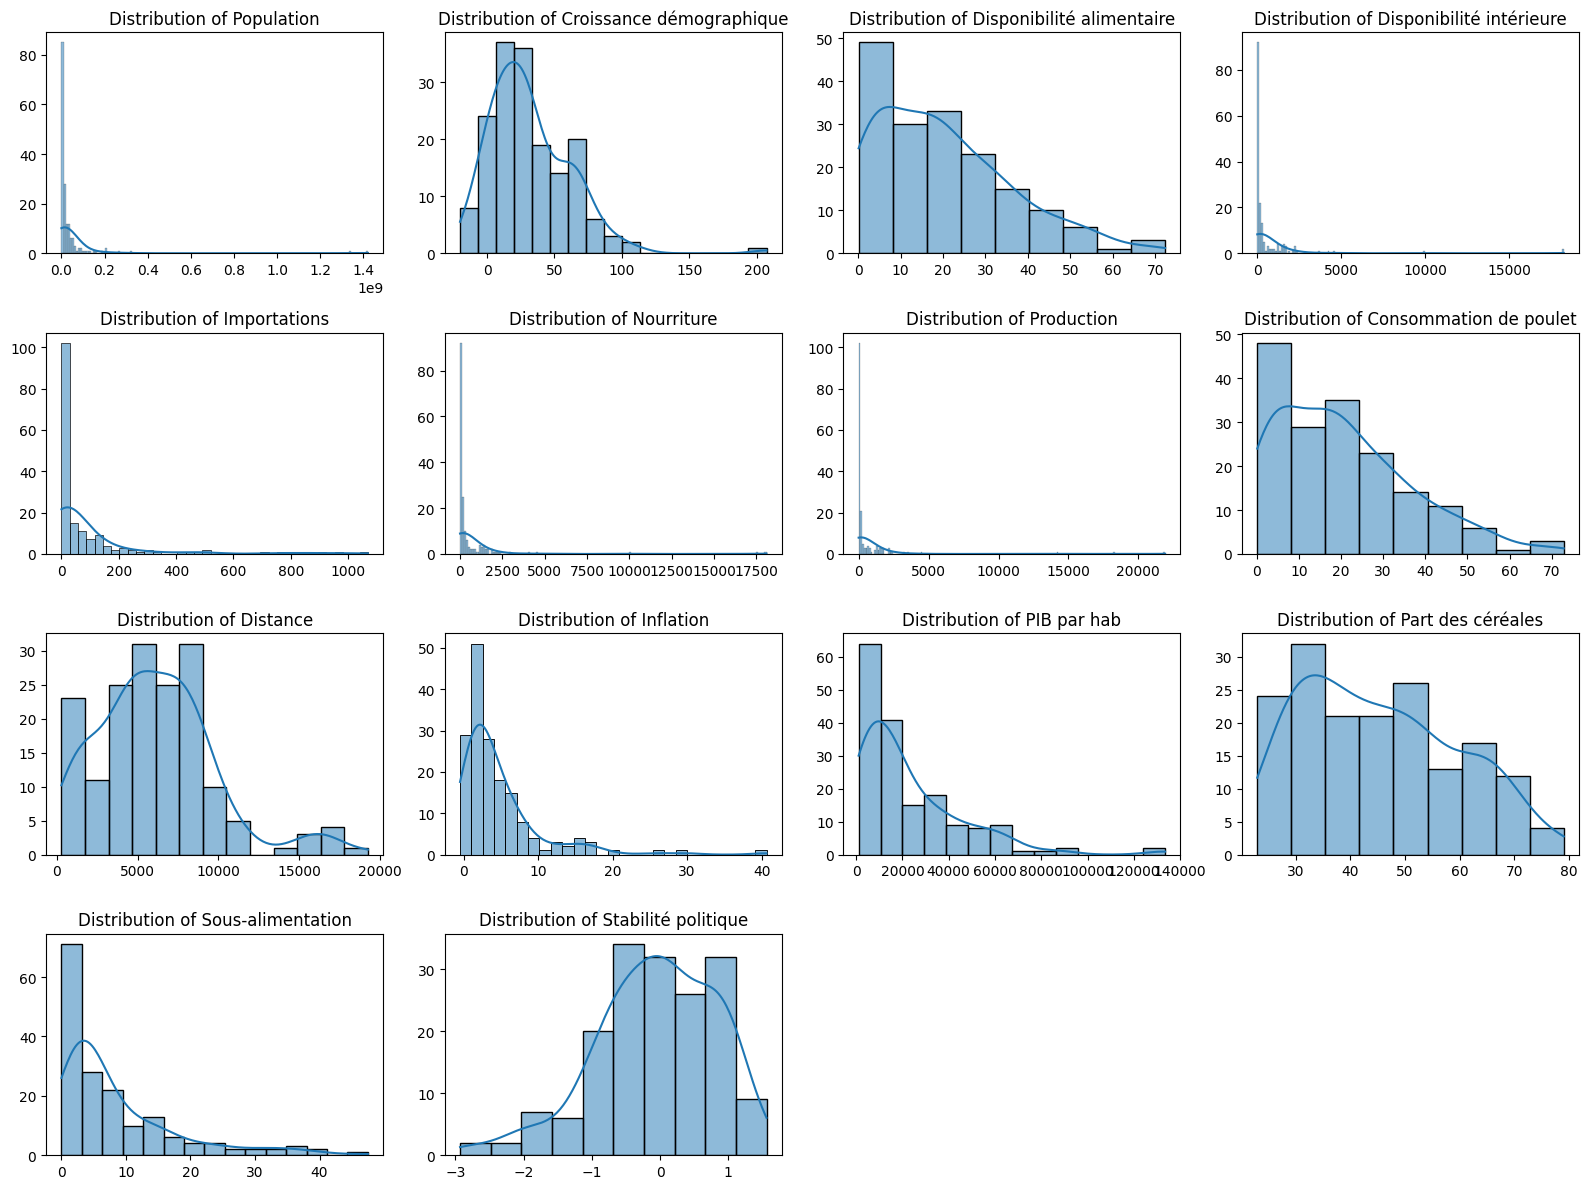

In [114]:
#On conserve le canevas utilisé précédemment
num_plots = len(df_final.columns)
rows = math.ceil(num_plots / 4)
cols = min(num_plots, 4)

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(4 * cols, 3 * rows))
axes = axes.flatten() # On aplatit le tableau des axes pour utiliser la boucle for

for i, column in enumerate(df_final.columns):
    sns.histplot(df_final[column], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Cachons les subplots inutilisés
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#5 : Export csv

In [115]:
##On réintroduit le nom des pays dans les colonnes pour ne pas perdre l'information passée en index
df_final['Zone']=df_final.index

df_final.head()

,Population,Croissance démographique,Disponibilité alimentaire,Disponibilité intérieure,Importations,Nourriture,Production,Consommation de poulet,Distance,Inflation,PIB par hab,Part des céréales,Sous-alimentation,Stabilité politique,Zone
Afghanistan,36296113.0,78.88,1.53,57.0,29.0,55.0,28.0,1.52,5590.381,3.58,2953.0,71.0,21.3,-2.79,Afghanistan
Afrique du Sud,57009756.0,28.52,35.69,2118.0,514.0,2035.0,1667.0,35.70,8692.812,6.50,14591.0,51.0,6.1,-0.28,Afrique du Sud
Albanie,2884169.0,-7.88,16.36,47.0,38.0,47.0,13.0,16.30,1603.534,2.29,14155.0,34.0,4.3,0.37,Albanie
Algérie,41389189.0,36.04,6.38,277.0,2.0,264.0,275.0,6.38,1340.390,6.66,15428.0,48.0,2.5,-0.92,Algérie
Allemagne,82658409.0,2.12,19.47,1739.0,842.0,1609.0,1514.0,19.47,880.187,1.44,61992.0,27.0,2.5,0.57,Allemagne


In [116]:
##Extraction du df en csv
df_final.to_csv("cleaned_data.csv", index=False)